# FinPulse Exploratory Data Analysis

This notebook explores the FinPulse transaction dataset stored in SQLite.

The goals are to:

1. Validate the generated user and transaction data.
2. Understand transaction volume and category distributions.
3. Explore income and spending patterns.
4. Examine monthly financial behavior.
5. Identify notable spending, repayment, savings, and overspending patterns.

Feature engineering for the production pipeline is handled separately through SQL and `scripts/build_features.py`.

In [171]:
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", None)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.2f}"
)


PROJECT_ROOT = Path.cwd().parent

DATABASE_FILE = (
    PROJECT_ROOT
    / "database"
    / "finpulse.db"
)

DATABASE_FILE

PosixPath('/Users/veer/Desktop/Finpulse/database/finpulse.db')

In [172]:
with sqlite3.connect(DATABASE_FILE) as conn:

    users = pd.read_sql_query(
        """
        SELECT *
        FROM users
        ORDER BY user_id
        """,
        conn
    )

    transactions = pd.read_sql_query(
        """
        SELECT *
        FROM transactions
        ORDER BY user_id, date
        """,
        conn,
        parse_dates=["date"]
    )

    monthly = pd.read_sql_query(
        """
        SELECT *
        FROM monthly_features
        ORDER BY user_id, month
        """,
        conn
    )


print("Users:", users.shape)
print("Transactions:", transactions.shape)
print("Monthly features:", monthly.shape)

Users: (1000, 2)
Transactions: (325943, 6)
Monthly features: (12000, 21)


In [173]:
display(users.head())

display(transactions.head())

display(monthly.head())

,user_id,base_monthly_income
0,U0001,"44,359.48"
1,U0002,"39,713.74"
2,U0003,"38,803.64"
3,U0004,"33,029.21"
4,U0005,"36,069.82"


,transaction_id,user_id,date,amount,txn_type,label
0,T0000004,U0001,2023-01-01,816.02,debit,Essentials
1,T0000018,U0001,2023-01-07,137.57,debit,Desire
2,T0000011,U0001,2023-01-09,"1,816.11",debit,Essentials
3,T0000019,U0001,2023-01-09,"1,014.33",debit,Desire
4,T0000020,U0001,2023-01-13,"1,520.61",debit,Desire


,user_id,month,income,essentials,desire,repayment,investment_savings,others,transaction_count,credit_transaction_count,debit_transaction_count,total_outflow,surplus,essential_ratio,desire_ratio,repayment_ratio,investment_ratio,other_ratio,expense_to_income_ratio,surplus_ratio,overspending_flag
0,U0001,2023-01,"42,957.63","17,181.91","4,424.85","21,360.67",0.00,"2,845.27",25,1,24,"45,812.70","-2,855.07",0.40,0.10,0.50,0.00,0.07,1.07,-0.07,1
1,U0001,2023-02,"43,271.70","15,700.30","3,762.96","19,356.14","1,253.80","2,265.01",24,1,23,"42,338.21",933.49,0.36,0.09,0.45,0.03,0.05,0.98,0.02,0
2,U0001,2023-03,"44,098.79","15,113.69","3,045.96","20,964.27","1,163.41","3,771.07",22,1,21,"44,058.40",40.39,0.34,0.07,0.48,0.03,0.09,1.00,0.00,0
3,U0001,2023-04,"45,162.28","16,222.75","3,961.15","24,130.97",0.00,"3,573.75",26,1,25,"47,888.62","-2,726.34",0.36,0.09,0.53,0.00,0.08,1.06,-0.06,1
4,U0001,2023-05,"43,584.60","16,630.48","4,052.02","21,054.65","1,139.46","2,421.88",29,1,28,"45,298.49","-1,713.89",0.38,0.09,0.48,0.03,0.06,1.04,-0.04,1


## 1. Data Quality

In [174]:
print("Users missing values:")
display(users.isnull().sum())

print("\nTransactions missing values:")
display(transactions.isnull().sum())

print("\nMonthly features missing values:")
display(monthly.isnull().sum())

Users missing values:


user_id                0
base_monthly_income    0
dtype: int64


Transactions missing values:


transaction_id    0
user_id           0
date              0
amount            0
txn_type          0
label             0
dtype: int64


Monthly features missing values:


user_id                     0
month                       0
income                      0
essentials                  0
desire                      0
repayment                   0
investment_savings          0
others                      0
transaction_count           0
credit_transaction_count    0
debit_transaction_count     0
total_outflow               0
surplus                     0
essential_ratio             0
desire_ratio                0
repayment_ratio             0
investment_ratio            0
other_ratio                 0
expense_to_income_ratio     0
surplus_ratio               0
overspending_flag           0
dtype: int64

In [175]:
print(
    "Duplicate user IDs:",
    users["user_id"].duplicated().sum()
)

print(
    "Duplicate transaction IDs:",
    transactions["transaction_id"]
    .duplicated()
    .sum()
)

print(
    "Duplicate user-month rows:",
    monthly[
        ["user_id", "month"]
    ].duplicated().sum()
)

Duplicate user IDs: 0
Duplicate transaction IDs: 0
Duplicate user-month rows: 0


In [176]:
registered_users = set(
    users["user_id"]
)

transaction_users = set(
    transactions["user_id"]
)

unknown_users = (
    transaction_users
    - registered_users
)

print(
    "Transactions belonging to unknown users:",
    len(unknown_users)
)

Transactions belonging to unknown users: 0


In [177]:
print(
    "First transaction:",
    transactions["date"].min()
)

print(
    "Last transaction:",
    transactions["date"].max()
)

print(
    "Zero or negative amounts:",
    (transactions["amount"] <= 0).sum()
)

print(
    "Unique users with transactions:",
    transactions["user_id"].nunique()
)

First transaction: 2023-01-01 00:00:00
Last transaction: 2023-12-31 00:00:00
Zero or negative amounts: 0
Unique users with transactions: 1000


## 2. Transaction Distribution

In [178]:
transactions[
    "txn_type"
].value_counts()

txn_type
debit     313943
credit     12000
Name: count, dtype: int64

In [179]:
pd.crosstab(
    transactions["label"],
    transactions["txn_type"]
)

txn_type,credit,debit
label,,
Desire,0,89807
Essentials,0,138270
Income,12000,0
Investment_Savings,0,20245
Others,0,41811
Repayment,0,23810


In [180]:
category_counts = (
    transactions["label"]
    .value_counts()
)

category_counts

label
Essentials            138270
Desire                 89807
Others                 41811
Repayment              23810
Investment_Savings     20245
Income                 12000
Name: count, dtype: int64

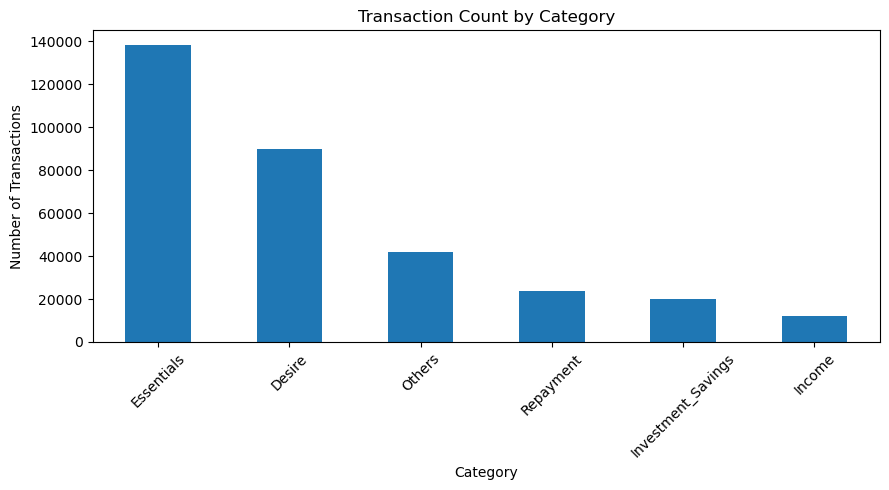

In [181]:
category_counts.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Transaction Count by Category"
)

plt.xlabel("Category")
plt.ylabel("Number of Transactions")

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

In [182]:
category_distribution = (
    transactions["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

category_distribution

label
Essentials           42.42
Desire               27.55
Others               12.83
Repayment             7.30
Investment_Savings    6.21
Income                3.68
Name: proportion, dtype: float64

## 3. Transaction Amount Analysis

In [183]:
transactions[
    "amount"
].describe()

count   325,943.00
mean      3,165.07
std       9,689.95
min           0.36
25%         435.98
50%         939.81
75%       1,942.44
max     173,985.47
Name: amount, dtype: float64

In [184]:
amount_by_category = (
    transactions
    .groupby("label")["amount"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max"
        ]
    )
    .round(2)
)

amount_by_category

,count,mean,median,min,max
label,,,,,
Desire,89807,"1,250.34",808.00,0.36,"20,350.67"
Essentials,138270,"1,436.15","1,048.07",0.79,"21,810.03"
Income,12000,"46,956.97","39,742.06","9,085.53","173,985.47"
Investment_Savings,20245,"1,921.75",853.81,1.97,"38,407.36"
Others,41811,650.70,429.32,0.81,"11,847.90"
Repayment,23810,"3,829.06","2,032.57",0.77,"52,599.32"


In [185]:
income_transactions = transactions[
    transactions["label"] == "Income"
]

income_transactions[
    "amount"
].describe()

count    12,000.00
mean     46,956.97
std      21,021.31
min       9,085.53
25%      32,659.88
50%      39,742.07
75%      55,886.19
max     173,985.47
Name: amount, dtype: float64

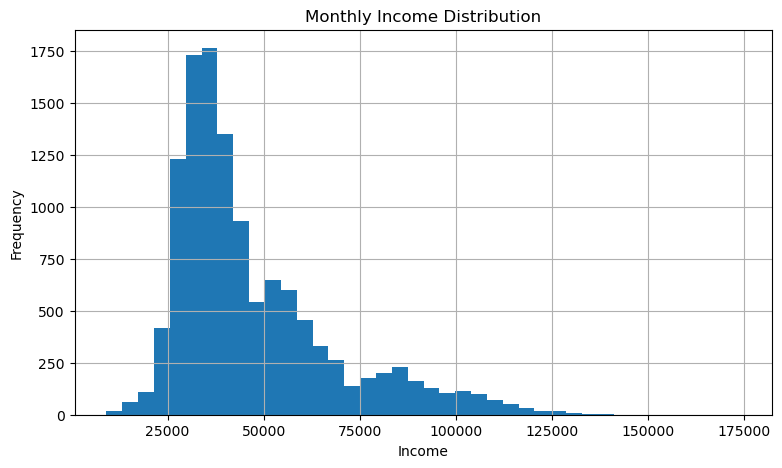

In [186]:
income_transactions[
    "amount"
].hist(
    bins=40,
    figsize=(9, 5)
)

plt.title(
    "Monthly Income Distribution"
)

plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

In [187]:
users[
    "base_monthly_income"
].describe()

count     1,000.00
mean     47,038.92
std      20,015.41
min      22,416.32
25%      33,036.30
50%      39,624.31
75%      55,456.49
max     117,790.01
Name: base_monthly_income, dtype: float64

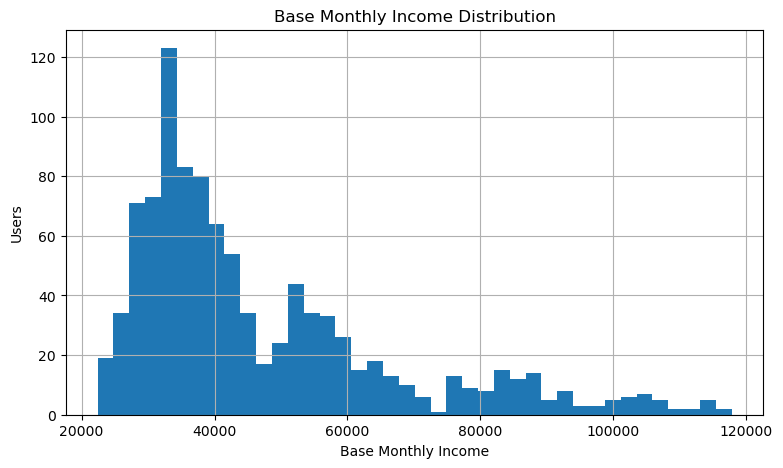

In [188]:
users[
    "base_monthly_income"
].hist(
    bins=40,
    figsize=(9, 5)
)

plt.title(
    "Base Monthly Income Distribution"
)

plt.xlabel(
    "Base Monthly Income"
)

plt.ylabel("Users")

plt.show()

## 4. User Activity

In [189]:
transactions_per_user = (
    transactions
    .groupby("user_id")
    .size()
)

transactions_per_user.describe()

count   1,000.00
mean      325.94
std        12.34
min       275.00
25%       318.00
50%       326.00
75%       334.00
max       364.00
dtype: float64

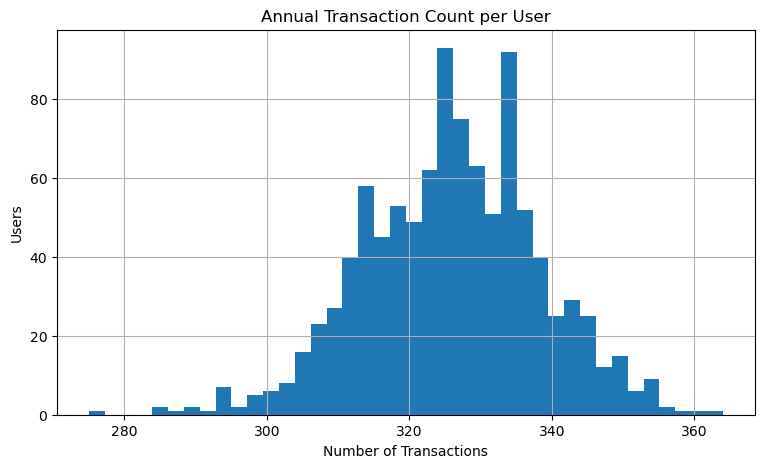

In [190]:
transactions_per_user.hist(
    bins=40,
    figsize=(9, 5)
)

plt.title(
    "Annual Transaction Count per User"
)

plt.xlabel(
    "Number of Transactions"
)

plt.ylabel("Users")

plt.show()

In [191]:
transactions["month"] = (
    transactions["date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_transaction_count = (
    transactions
    .groupby("month")
    .size()
)

monthly_transaction_count

month
2023-01    27215
2023-02    27333
2023-03    27020
2023-04    27348
2023-05    27264
2023-06    27019
2023-07    27164
2023-08    26994
2023-09    27190
2023-10    27074
2023-11    27211
2023-12    27111
dtype: int64

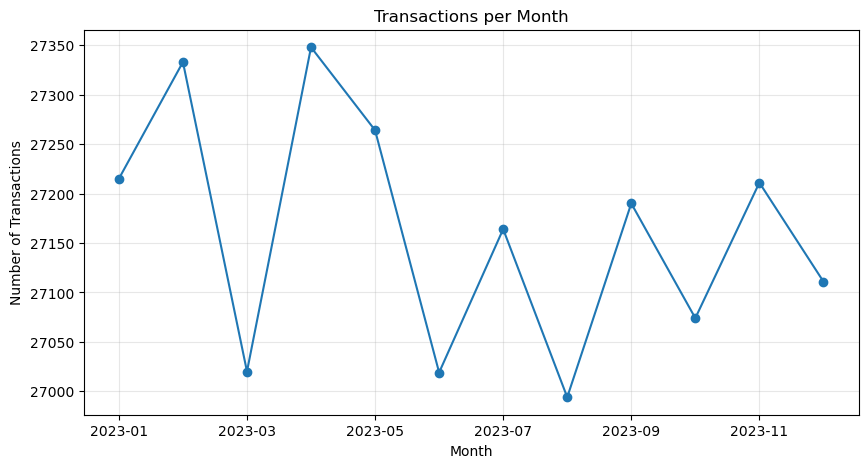

In [192]:
monthly_transaction_count.plot(
    figsize=(10, 5),
    marker="o"
)

plt.title(
    "Transactions per Month"
)

plt.xlabel("Month")
plt.ylabel(
    "Number of Transactions"
)

plt.grid(alpha=0.3)

plt.show()

## 5. Monthly Financial Behaviour

The production `monthly_features` table is created by the SQL analytics pipeline, so the notebook analyzes that table instead of rebuilding the same features with Pandas.

In [193]:
monthly_columns = [
    "income",
    "essentials",
    "desire",
    "repayment",
    "investment_savings",
    "others",
    "total_outflow",
    "surplus",
]

monthly[
    monthly_columns
].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
income,"12,000.00","46,956.97","21,021.31","9,085.53","32,659.88","39,742.06","55,886.19","173,985.47"
essentials,"12,000.00","16,548.02","7,762.59","3,163.76","11,105.21","14,055.60","19,889.28","75,385.36"
desire,"12,000.00","9,357.45","6,544.30",876.28,"4,732.02","7,475.50","11,894.37","55,397.00"
repayment,"12,000.00","7,597.49","7,809.76",0.00,"2,608.95","4,713.10","10,270.73","57,205.36"
investment_savings,"12,000.00","3,242.16","4,209.42",0.00,447.92,"1,482.20","4,621.99","38,407.36"
others,"12,000.00","2,267.21","1,717.56",0.00,"1,172.44","1,805.31","2,810.43","23,693.99"
total_outflow,"12,000.00","39,012.34","18,537.76","5,884.92","26,166.74","33,609.19","46,734.90","136,439.20"
surplus,"12,000.00","7,944.63","8,134.35","-19,359.17","2,866.56","6,855.80","11,381.82","56,333.77"


In [194]:
ratio_columns = [
    "essential_ratio",
    "desire_ratio",
    "repayment_ratio",
    "investment_ratio",
    "other_ratio",
    "expense_to_income_ratio",
    "surplus_ratio",
]

monthly[
    ratio_columns
].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
essential_ratio,"12,000.00",0.35,0.05,0.21,0.32,0.35,0.39,0.53
desire_ratio,"12,000.00",0.20,0.10,0.04,0.12,0.17,0.26,0.71
repayment_ratio,"12,000.00",0.16,0.14,0.00,0.07,0.12,0.17,0.59
investment_ratio,"12,000.00",0.07,0.08,0.00,0.01,0.03,0.12,0.38
other_ratio,"12,000.00",0.05,0.03,0.00,0.03,0.04,0.06,0.22
expense_to_income_ratio,"12,000.00",0.83,0.14,0.43,0.73,0.82,0.93,1.30
surplus_ratio,"12,000.00",0.17,0.14,-0.30,0.07,0.18,0.27,0.57


In [195]:
average_allocation = (
    monthly[
        [
            "essential_ratio",
            "desire_ratio",
            "repayment_ratio",
            "investment_ratio",
            "other_ratio",
        ]
    ]
    .mean()
    .mul(100)
    .round(2)
)

average_allocation

essential_ratio    35.27
desire_ratio       20.04
repayment_ratio    16.07
investment_ratio    6.87
other_ratio         4.84
dtype: float64

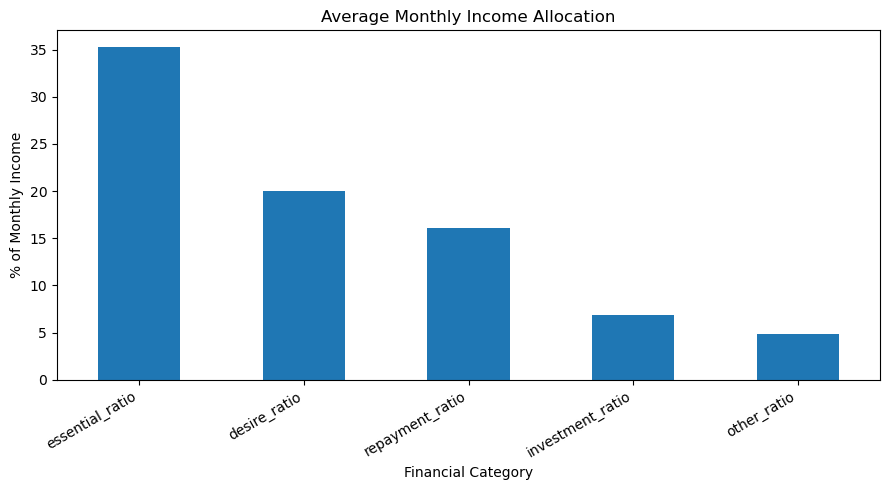

In [196]:
average_allocation.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Average Monthly Income Allocation"
)

plt.xlabel(
    "Financial Category"
)

plt.ylabel(
    "% of Monthly Income"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()

## 6. Spending Pressure and Overspending

In [197]:
overspending_months = (
    monthly["overspending_flag"]
    .sum()
)

overspending_percentage = (
    monthly["overspending_flag"]
    .mean()
    * 100
)

print(
    "Overspending user-months:",
    int(overspending_months)
)

print(
    "Percentage of user-months:",
    f"{overspending_percentage:.2f}%"
)

Overspending user-months: 1461
Percentage of user-months: 12.17%


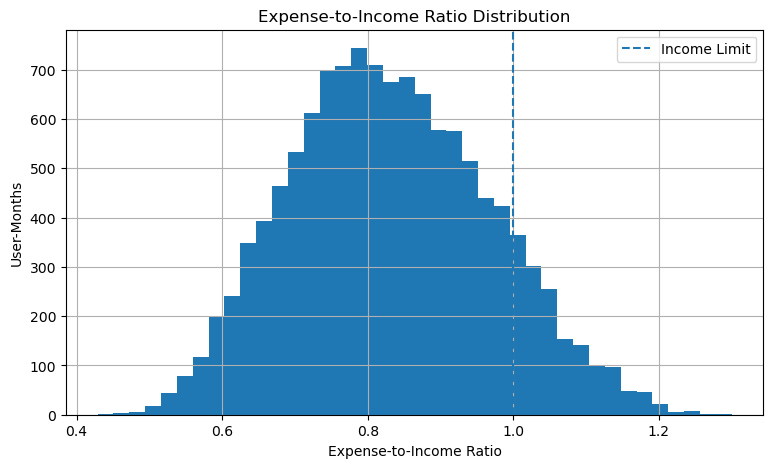

In [198]:
monthly[
    "expense_to_income_ratio"
].hist(
    bins=40,
    figsize=(9, 5)
)

plt.axvline(
    1.0,
    linestyle="--",
    label="Income Limit"
)

plt.title(
    "Expense-to-Income Ratio Distribution"
)

plt.xlabel(
    "Expense-to-Income Ratio"
)

plt.ylabel(
    "User-Months"
)

plt.legend()

plt.show()

In [199]:
monthly.nlargest(
    10,
    "expense_to_income_ratio"
)[
    [
        "user_id",
        "month",
        "income",
        "total_outflow",
        "expense_to_income_ratio",
        "surplus",
    ]
]

,user_id,month,income,total_outflow,expense_to_income_ratio,surplus
1720,U0144,2023-05,"64,530.55","83,889.72",1.30,"-19,359.17"
9765,U0814,2023-10,"42,689.60","53,650.85",1.26,"-10,961.25"
2852,U0238,2023-09,"57,699.72","72,168.02",1.25,"-14,468.30"
6387,U0533,2023-04,"65,617.69","82,016.80",1.25,"-16,399.11"
10244,U0854,2023-09,"42,129.21","52,650.98",1.25,"-10,521.77"
3231,U0270,2023-04,"53,677.49","66,790.03",1.24,"-13,112.54"
6437,U0537,2023-06,"48,547.46","60,380.86",1.24,"-11,833.40"
6722,U0561,2023-03,"26,673.06","33,129.52",1.24,"-6,456.46"
8971,U0748,2023-08,"36,848.25","45,531.66",1.24,"-8,683.41"
11875,U0990,2023-08,"29,028.46","35,826.34",1.23,"-6,797.88"


## 7. Behavioral Extremes

In [200]:
monthly.nlargest(
    10,
    "desire_ratio"
)[
    [
        "user_id",
        "month",
        "income",
        "desire",
        "desire_ratio",
    ]
]

,user_id,month,income,desire,desire_ratio
11389,U0950,2023-02,"30,619.43","21,683.80",0.71
9110,U0760,2023-03,"30,401.20","20,508.55",0.67
5363,U0447,2023-12,"47,969.98","29,671.82",0.62
8768,U0731,2023-09,"53,639.09","32,662.99",0.61
2893,U0242,2023-02,"50,152.42","30,348.82",0.61
11064,U0923,2023-01,"35,998.14","21,594.93",0.60
656,U0055,2023-09,"43,897.94","26,304.06",0.60
1584,U0133,2023-01,"63,817.51","37,883.71",0.59
11192,U0933,2023-09,"26,087.56","15,396.41",0.59
8409,U0701,2023-10,"25,437.31","15,006.96",0.59


In [201]:
monthly.nlargest(
    10,
    "repayment_ratio"
)[
    [
        "user_id",
        "month",
        "income",
        "repayment",
        "repayment_ratio",
    ]
]

,user_id,month,income,repayment,repayment_ratio
7877,U0657,2023-06,"32,968.66","19,464.55",0.59
10350,U0863,2023-07,"30,317.21","17,666.17",0.58
3237,U0270,2023-10,"48,843.45","27,663.57",0.57
9157,U0764,2023-02,"33,774.73","18,990.23",0.56
509,U0043,2023-06,"56,352.02","31,382.25",0.56
10353,U0863,2023-10,"33,312.02","18,539.78",0.56
10473,U0873,2023-10,"32,172.81","17,902.75",0.56
8849,U0738,2023-06,"32,636.48","18,071.43",0.55
9854,U0822,2023-03,"58,888.60","32,590.18",0.55
7587,U0633,2023-04,"22,865.64","12,610.62",0.55


In [202]:
monthly.nlargest(
    10,
    "investment_ratio"
)[
    [
        "user_id",
        "month",
        "income",
        "investment_savings",
        "investment_ratio",
    ]
]

,user_id,month,income,investment_savings,investment_ratio
8903,U0742,2023-12,"25,001.17","9,497.55",0.38
80,U0007,2023-09,"33,856.15","12,309.90",0.36
5975,U0498,2023-12,"31,538.99","10,909.73",0.35
4644,U0388,2023-01,"31,714.11","10,939.04",0.34
3579,U0299,2023-04,"58,834.73","20,255.43",0.34
3053,U0255,2023-06,"30,506.40","10,376.68",0.34
10562,U0881,2023-03,"83,941.23","27,748.56",0.33
1811,U0151,2023-12,"61,513.25","20,155.77",0.33
2466,U0206,2023-07,"42,608.45","13,855.06",0.33
1015,U0085,2023-08,"36,583.62","11,883.29",0.32


In [203]:
monthly.nsmallest(
    10,
    "surplus"
)[
    [
        "user_id",
        "month",
        "income",
        "total_outflow",
        "surplus",
    ]
]

,user_id,month,income,total_outflow,surplus
1720,U0144,2023-05,"64,530.55","83,889.72","-19,359.17"
8486,U0708,2023-03,"87,358.35","104,802.30","-17,443.95"
1912,U0160,2023-05,"89,443.17","106,241.00","-16,797.83"
1908,U0160,2023-01,"96,766.40","113,550.33","-16,783.93"
6387,U0533,2023-04,"65,617.69","82,016.80","-16,399.11"
6486,U0541,2023-07,"85,515.57","100,908.37","-15,392.80"
9324,U0778,2023-01,"109,380.69","124,587.61","-15,206.92"
9894,U0825,2023-07,"83,520.51","98,554.21","-15,033.70"
1918,U0160,2023-11,"96,821.84","111,775.83","-14,953.99"
2852,U0238,2023-09,"57,699.72","72,168.02","-14,468.30"


## 8. Population-Level Monthly Trends

In [204]:
population_monthly = (
    monthly
    .groupby("month")
    .agg(
        avg_expense_ratio=(
            "expense_to_income_ratio",
            "mean"
        ),
        avg_desire_ratio=(
            "desire_ratio",
            "mean"
        ),
        avg_repayment_ratio=(
            "repayment_ratio",
            "mean"
        ),
        avg_investment_ratio=(
            "investment_ratio",
            "mean"
        ),
        overspending_rate=(
            "overspending_flag",
            "mean"
        ),
    )
)

population_monthly.round(4)

,avg_expense_ratio,avg_desire_ratio,avg_repayment_ratio,avg_investment_ratio,overspending_rate
month,,,,,
2023-01,0.83,0.20,0.16,0.07,0.12
2023-02,0.83,0.20,0.16,0.07,0.13
2023-03,0.83,0.20,0.16,0.07,0.13
2023-04,0.83,0.20,0.16,0.07,0.12
2023-05,0.83,0.20,0.16,0.07,0.12
2023-06,0.83,0.20,0.16,0.07,0.11
2023-07,0.83,0.20,0.16,0.07,0.14
2023-08,0.83,0.20,0.16,0.07,0.12
2023-09,0.83,0.20,0.16,0.07,0.12


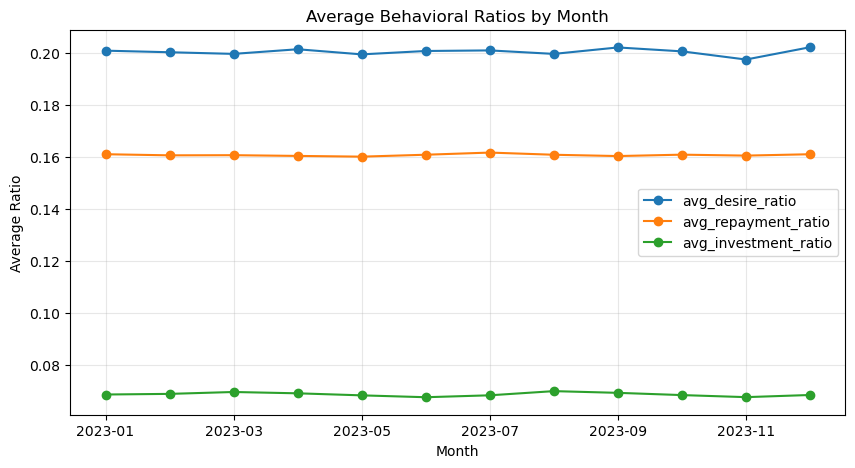

In [205]:
population_monthly[
    [
        "avg_desire_ratio",
        "avg_repayment_ratio",
        "avg_investment_ratio",
    ]
].plot(
    figsize=(10, 5),
    marker="o"
)

plt.title(
    "Average Behavioral Ratios by Month"
)

plt.xlabel("Month")
plt.ylabel(
    "Average Ratio"
)

plt.grid(alpha=0.3)

plt.show()

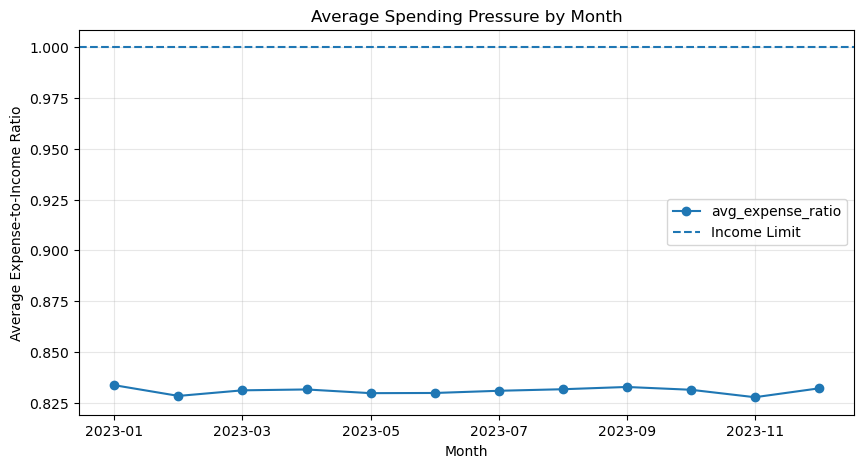

In [206]:
population_monthly[
    "avg_expense_ratio"
].plot(
    figsize=(10, 5),
    marker="o"
)

plt.axhline(
    1.0,
    linestyle="--",
    label="Income Limit"
)

plt.title(
    "Average Spending Pressure by Month"
)

plt.xlabel("Month")
plt.ylabel(
    "Average Expense-to-Income Ratio"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 9. Example User Behaviour

A single user is examined below only to illustrate how FinPulse represents behavior over time.

In [207]:
example_user_id = "U1000"

example_user = (
    monthly[
        monthly["user_id"]
        == example_user_id
    ]
    .copy()
)

example_user[
    [
        "month",
        "income",
        "essential_ratio",
        "desire_ratio",
        "repayment_ratio",
        "investment_ratio",
        "expense_to_income_ratio",
        "surplus",
    ]
]

,month,income,essential_ratio,desire_ratio,repayment_ratio,investment_ratio,expense_to_income_ratio,surplus
11988,2023-01,"41,569.31",0.40,0.19,0.11,0.00,0.80,"8,253.72"
11989,2023-02,"37,428.51",0.40,0.12,0.11,0.03,0.70,"11,364.93"
11990,2023-03,"24,714.23",0.40,0.17,0.10,0.00,0.68,"7,959.34"
11991,2023-04,"35,242.32",0.40,0.15,0.12,0.00,0.69,"10,755.17"
11992,2023-05,"38,421.68",0.46,0.20,0.12,0.02,0.82,"7,055.78"
11993,2023-06,"31,775.04",0.38,0.20,0.10,0.03,0.76,"7,660.08"
11994,2023-07,"34,227.23",0.40,0.19,0.10,0.05,0.85,"5,050.91"
11995,2023-08,"22,106.35",0.42,0.19,0.10,0.04,0.78,"4,899.06"
11996,2023-09,"34,324.64",0.38,0.21,0.10,0.00,0.71,"9,818.25"
11997,2023-10,"29,774.13",0.43,0.15,0.11,0.03,0.75,"7,554.10"


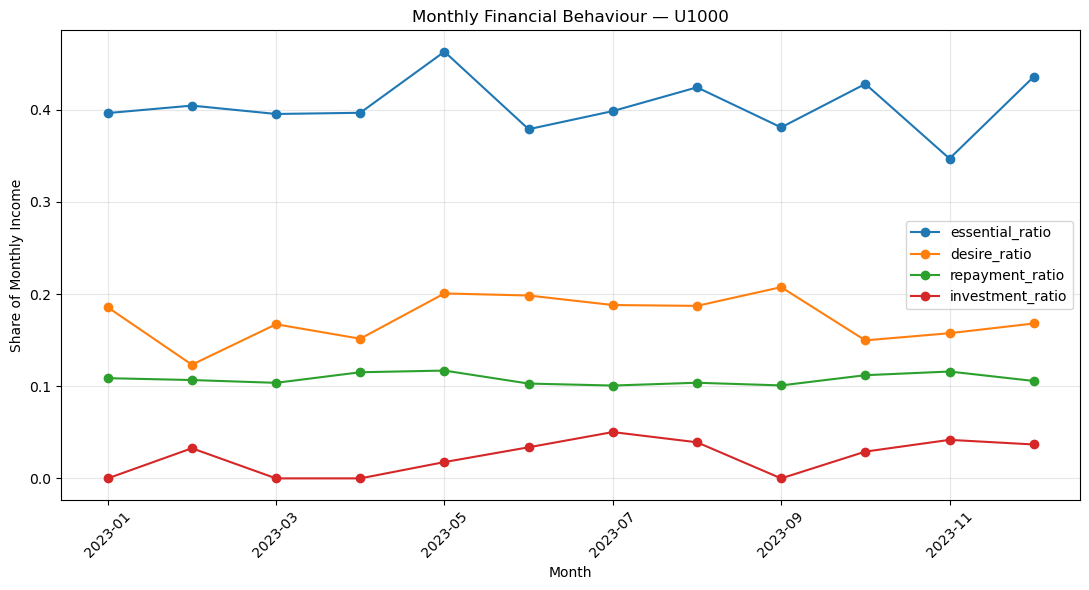

In [208]:
example_user.plot(
    x="month",
    y=[
        "essential_ratio",
        "desire_ratio",
        "repayment_ratio",
        "investment_ratio",
    ],
    figsize=(11, 6),
    marker="o"
)

plt.title(
    f"Monthly Financial Behaviour — {example_user_id}"
)

plt.xlabel("Month")
plt.ylabel(
    "Share of Monthly Income"
)

plt.xticks(
    rotation=45
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Conclusion

The FinPulse dataset contains transaction histories for 1,000 synthetic users across twelve months.

The exploratory analysis verifies the integrity of the transaction data and highlights meaningful differences in discretionary spending, repayment burden, savings allocation, income usage, and overspending behavior.

The production analytics pipeline converts these transaction-level records into reusable monthly and user-level behavioral features using SQL and Python.

These engineered features are subsequently used by:

- the KMeans behavioral segmentation model,
- the FinPulse scoring engine,
- behavioral signal generation,
- and the recommendation engine.

This notebook is intentionally limited to exploratory analysis and does not duplicate the production feature-engineering pipeline.